# Textile Defect — Anomaly Detection + Localization
(Requirement 7: Defect Localization, Requirement 11: Anomaly Detection)

Trains a **convolutional autoencoder** on `good` (normal) fabric images only. It learns to reconstruct normal texture well; when given a defective image, it fails to reconstruct the defect region, so the **pixel-wise reconstruction error becomes a heatmap that localizes the defect** — no bounding-box labels required, which matters since this dataset only has whole-image labels.

This is a separate model from the CNN classifier notebook (`classifier_v1`) — this one is `anomaly_v1`. Same data source, same leakage-safe split logic, different model/objective.

**Before running:** upload `train64.csv`, `train64.h5`, `test64.csv`, `test64.h5` (or the 32x32 versions) into one folder in your Google Drive — same folder as the classifier notebook uses.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install h5py -q

In [3]:
import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


## 1. Set paths

In [4]:
BASE_DIR = '/content/drive/MyDrive/textile/'  # <-- change if your folder name differs
RES = 64  # or 32

train_csv_path = BASE_DIR + f'train{RES}.csv'
test_csv_path  = BASE_DIR + f'test{RES}.csv'
train_h5_path  = BASE_DIR + f'train{RES}.h5'
test_h5_path   = BASE_DIR + f'test{RES}.h5'

## 2. Inspect the .h5 files

In [5]:
def inspect_h5(path):
    with h5py.File(path, 'r') as f:
        keys = list(f.keys())
        print(path)
        for k in keys:
            print(f'  key: {k!r}  shape: {f[k].shape}  dtype: {f[k].dtype}')
        return keys

train_keys = inspect_h5(train_h5_path)
test_keys  = inspect_h5(test_h5_path)

/content/drive/MyDrive/textile/train64.h5
  key: 'images'  shape: (48000, 64, 64, 1)  dtype: float32
/content/drive/MyDrive/textile/test64.h5
  key: 'images'  shape: (48000, 64, 64, 1)  dtype: float32


In [6]:
TRAIN_IMG_KEY = train_keys[0]
TEST_IMG_KEY  = test_keys[0]
print('Using key:', TRAIN_IMG_KEY, '/', TEST_IMG_KEY)

Using key: images / images


## 3. Load labels and confirm alignment

In [7]:
train_df = pd.read_csv(train_csv_path)
test_df  = pd.read_csv(test_csv_path)

print('train_df shape:', train_df.shape)
print('test_df shape:', test_df.shape)

with h5py.File(train_h5_path, 'r') as f:
    n_images_train = f[TRAIN_IMG_KEY].shape[0]
with h5py.File(test_h5_path, 'r') as f:
    n_images_test = f[TEST_IMG_KEY].shape[0]

assert n_images_train == len(train_df)
assert n_images_test == len(test_df)
print('shapes confirmed aligned')

train_df shape: (48000, 5)
test_df shape: (48000, 5)
shapes confirmed aligned


## 4. Combine train + test pools
Same reasoning as the classifier notebook: the provider's 50/50 split doesn't match the 70/15/15 the assignment wants, so we merge and re-split.

In [8]:
train_full_df = train_df.copy()
train_full_df['source'] = 'train_file'
train_full_df['h5_row'] = np.arange(len(train_full_df))

test_full_df = test_df.copy()
test_full_df['source'] = 'test_file'
test_full_df['h5_row'] = np.arange(len(test_full_df))

full_df = pd.concat([train_full_df, test_full_df], ignore_index=True)
print('combined pool size:', len(full_df))
full_df.head()

combined pool size: 96000


,index,angle,indication_type,indication_value,split,source,h5_row
0,48000,0,good,0,train,train_file,0
1,48001,80,good,0,train,train_file,1
2,48002,100,good,0,train,train_file,2
3,48003,100,good,0,train,train_file,3
4,48004,0,good,0,train,train_file,4


## 5. Encode labels

In [9]:
label_encoder = LabelEncoder()
label_encoder.fit(full_df['indication_type'])
NUM_CLASSES = len(label_encoder.classes_)
print('Classes:', list(label_encoder.classes_))

full_df['label'] = label_encoder.transform(full_df['indication_type'])

Classes: ['color', 'cut', 'good', 'hole', 'metal_contamination', 'thread']


## 6. Train / validation / test split (leakage-safe, exact-hash dedup)
Same approach as the classifier notebook — kept identical here so both notebooks evaluate on comparable splits. See the classifier notebook for the full explanation/limitations of this method.

In [10]:
import hashlib

def hash_image(img_array):
    rounded = np.round(np.asarray(img_array, dtype=np.float32) * 255).astype(np.uint8)
    return hashlib.md5(rounded.tobytes()).hexdigest()

hashes = [None] * len(full_df)

with h5py.File(train_h5_path, 'r') as f_train, h5py.File(test_h5_path, 'r') as f_test:
    train_imgs = f_train[TRAIN_IMG_KEY]
    test_imgs = f_test[TEST_IMG_KEY]

    for i, row in full_df.iterrows():
        img = train_imgs[row['h5_row']] if row['source'] == 'train_file' else test_imgs[row['h5_row']]
        hashes[i] = hash_image(img)

full_df['img_hash'] = hashes
print(f"{full_df['img_hash'].duplicated().sum()} rows share a hash with an earlier row.")

391 rows share a hash with an earlier row.


In [11]:
from sklearn.model_selection import GroupShuffleSplit

gss1 = GroupShuffleSplit(n_splits=1, train_size=0.70, random_state=42)
train_pos, temp_pos = next(gss1.split(full_df, groups=full_df['img_hash']))
temp_df = full_df.iloc[temp_pos]

gss2 = GroupShuffleSplit(n_splits=1, train_size=0.50, random_state=42)
val_pos_rel, test_pos_rel = next(gss2.split(temp_df, groups=temp_df['img_hash']))

train_split_full = full_df.iloc[train_pos].reset_index(drop=True)
val_split_full   = temp_df.iloc[val_pos_rel].reset_index(drop=True)
test_split_full  = temp_df.iloc[test_pos_rel].reset_index(drop=True)

print('train:', len(train_split_full), f'({len(train_split_full)/len(full_df):.1%})')
print('val:  ', len(val_split_full), f'({len(val_split_full)/len(full_df):.1%})')
print('test: ', len(test_split_full), f'({len(test_split_full)/len(full_df):.1%})')

train_hashes = set(train_split_full['img_hash'])
val_hashes   = set(val_split_full['img_hash'])
test_hashes  = set(test_split_full['img_hash'])
assert not (train_hashes & val_hashes)
assert not (train_hashes & test_hashes)
assert not (val_hashes & test_hashes)
print('No image hash appears across more than one split. Leakage check passed.')

train: 67197 (70.0%)
val:   14395 (15.0%)
test:  14408 (15.0%)
No image hash appears across more than one split. Leakage check passed.


## 7. Dataset class (combined-source aware)

In [12]:
class TextileDefectDataset(Dataset):
    def __init__(self, df, train_h5_path, train_img_key, test_h5_path, test_img_key):
        self.train_h5_path = train_h5_path
        self.train_img_key = train_img_key
        self.test_h5_path = test_h5_path
        self.test_img_key = test_img_key

        self.sources = df['source'].to_numpy()
        self.h5_rows = df['h5_row'].to_numpy()
        self.labels = df['label'].to_numpy()

        self._h5_train = None
        self._h5_test = None

    def _get_h5(self, source):
        if source == 'train_file':
            if self._h5_train is None:
                self._h5_train = h5py.File(self.train_h5_path, 'r')
            return self._h5_train, self.train_img_key
        else:
            if self._h5_test is None:
                self._h5_test = h5py.File(self.test_h5_path, 'r')
            return self._h5_test, self.test_img_key

    def __len__(self):
        return len(self.h5_rows)

    def __getitem__(self, idx):
        h5, img_key = self._get_h5(self.sources[idx])
        h5_row = int(self.h5_rows[idx])
        img = h5[img_key][h5_row]
        img = np.asarray(img, dtype=np.float32)

        if img.max() > 1.0:
            img = img / 255.0

        if img.ndim == 2:
            img = img[None, :, :]
        elif img.ndim == 3 and img.shape[-1] in (1, 3):
            img = np.transpose(img, (2, 0, 1))

        label = int(self.labels[idx])
        return torch.from_numpy(img), label

In [13]:
val_dataset  = TextileDefectDataset(val_split_full, train_h5_path, TRAIN_IMG_KEY, test_h5_path, TEST_IMG_KEY)
test_dataset = TextileDefectDataset(test_split_full, train_h5_path, TRAIN_IMG_KEY, test_h5_path, TEST_IMG_KEY)

sample_img, sample_label = test_dataset[0]
IN_CHANNELS = sample_img.shape[0]
print('image tensor shape:', sample_img.shape)

image tensor shape: torch.Size([1, 64, 64])


## 8. Build a `good`-only training set
Anomaly models are trained ONLY on normal samples — the model must never see a defect during training, or it would learn to reconstruct defects too and the whole trick stops working.

In [14]:
BATCH_SIZE = 64
good_label = label_encoder.transform(['good'])[0]

train_good_full = train_split_full[train_split_full['label'] == good_label].reset_index(drop=True)
val_good_full   = val_split_full[val_split_full['label'] == good_label].reset_index(drop=True)
print('good-only training samples:', len(train_good_full))
print('good-only validation samples:', len(val_good_full))

train_good_dataset = TextileDefectDataset(train_good_full, train_h5_path, TRAIN_IMG_KEY, test_h5_path, TEST_IMG_KEY)
val_good_dataset   = TextileDefectDataset(val_good_full, train_h5_path, TRAIN_IMG_KEY, test_h5_path, TEST_IMG_KEY)

train_good_loader = DataLoader(train_good_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_good_loader   = DataLoader(val_good_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# test_dataset stays MIXED (good + all defect types) — we need defects present to evaluate detection
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

good-only training samples: 11166
good-only validation samples: 2394


## 9. Autoencoder architecture

In [15]:
class ConvAutoencoder(nn.Module):
    # NOTE on the last two attempts:
    #  v1: 128ch @ 8x8 bottleneck (8,192-dim) -> reconstructed defects too
    #      well, ROC-AUC 0.57 (barely above chance).
    #  v2: 64ch @ 4x4 bottleneck (1,024-dim), still fully convolutional ->
    #      ROC-AUC dropped to 0.4791 (worse than random!). Cause: a purely
    #      convolutional bottleneck still preserves spatial correspondence
    #      between each bottleneck unit and a specific image patch, so the
    #      decoder can reconstruct almost any local patch reasonably well
    #      -- normal or defective. With capacity narrowed, the starved model
    #      actually reconstructed large flat defect regions (metal
    #      contamination, color blocks) MORE easily than the fine repetitive
    #      weave texture of normal fabric, which flipped the anomaly signal.
    #  v3 (this version): adds a genuine dense (Linear) bottleneck that
    #      flattens the whole image into one small vector before decoding.
    #      This removes the spatial pass-through entirely -- the model must
    #      compress the WHOLE image into a compact global code, so it can
    #      only decode well what it has actually learned to represent
    #      (normal, repetitive fabric texture), not arbitrary local patches.
    #      This is the standard, defensible design for AE-based anomaly
    #      detection. latent_dim=16 (down from an initial 64): at 64-dim
    #      the code could still store simple global stats (average
    #      color/brightness, blob location) good enough to reconstruct
    #      large, low-frequency defects (color blocks, metal
    #      contamination) almost as easily as normal texture -- AUC only
    #      reached 0.5655. Forcing a much smaller code should make it
    #      keep enough capacity for repetitive normal texture but not
    #      for irregular anomalies.
    def __init__(self, in_channels, latent_dim=16):
        super().__init__()
        self.conv_encoder = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, stride=2, padding=1),  # 64 -> 32
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),           # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),           # 16 -> 8
            nn.ReLU(),
        )
        self._flat_dim = 64 * 8 * 8
        self.to_latent = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._flat_dim, latent_dim),
            nn.ReLU(),
        )
        self.from_latent = nn.Sequential(
            nn.Linear(latent_dim, self._flat_dim),
            nn.ReLU(),
        )
        self.conv_decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),  # 8 -> 16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),  # 16 -> 32
            nn.ReLU(),
            nn.ConvTranspose2d(16, in_channels, 3, stride=2, padding=1, output_padding=1),  # 32 -> 64
            nn.Sigmoid(),
        )

    def forward(self, x):
        feat = self.conv_encoder(x)
        z = self.to_latent(feat)
        feat_recon = self.from_latent(z)
        feat_recon = feat_recon.view(-1, 64, 8, 8)
        return self.conv_decoder(feat_recon)

autoencoder = ConvAutoencoder(IN_CHANNELS, latent_dim=16).to(device)
print(autoencoder)

ConvAutoencoder(
  (conv_encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (to_latent): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=16, bias=True)
    (2): ReLU()
  )
  (from_latent): Sequential(
    (0): Linear(in_features=16, out_features=4096, bias=True)
    (1): ReLU()
  )
  (conv_decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (5): Sigmoid()
  )
)


## 10. Train the autoencoder (good images only)

In [16]:
ae_criterion = nn.MSELoss()
ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)
ae_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(ae_optimizer, mode='min', factor=0.5, patience=2)

AE_EPOCHS = 20
AE_PATIENCE = 5
BEST_AE_PATH = BASE_DIR + 'best_autoencoder.pt'   # Drive, not the ephemeral Colab runtime

def run_ae_epoch(loader, train=True):
    autoencoder.train() if train else autoencoder.eval()
    total_loss, total = 0.0, 0

    with torch.set_grad_enabled(train):
        for images, _ in loader:
            images = images.to(device)

            if train:
                ae_optimizer.zero_grad()

            recon = autoencoder(images)
            loss = ae_criterion(recon, images)

            if train:
                loss.backward()
                ae_optimizer.step()

            total_loss += loss.item() * images.size(0)
            total += images.size(0)

    return total_loss / total

In [17]:
ae_history = {'train_loss': [], 'val_loss': []}
best_ae_val_loss = float('inf')
ae_epochs_no_improve = 0

for epoch in range(1, AE_EPOCHS + 1):
    train_loss = run_ae_epoch(train_good_loader, train=True)
    val_loss = run_ae_epoch(val_good_loader, train=False)
    ae_scheduler.step(val_loss)

    ae_history['train_loss'].append(train_loss)
    ae_history['val_loss'].append(val_loss)

    print(f'Epoch {epoch:02d}/{AE_EPOCHS} | train_loss {train_loss:.5f} | val_loss {val_loss:.5f}')

    if val_loss < best_ae_val_loss:
        best_ae_val_loss = val_loss
        ae_epochs_no_improve = 0
        torch.save(autoencoder.state_dict(), BEST_AE_PATH)
    else:
        ae_epochs_no_improve += 1
        if ae_epochs_no_improve >= AE_PATIENCE:
            print(f'Early stopping at epoch {epoch}')
            break

autoencoder.load_state_dict(torch.load(BEST_AE_PATH))

Epoch 01/20 | train_loss 0.02650 | val_loss 0.01839
Epoch 02/20 | train_loss 0.01654 | val_loss 0.01537
Epoch 03/20 | train_loss 0.01471 | val_loss 0.01450
Epoch 04/20 | train_loss 0.01419 | val_loss 0.01417
Epoch 05/20 | train_loss 0.01399 | val_loss 0.01405
Epoch 06/20 | train_loss 0.01388 | val_loss 0.01394
Epoch 07/20 | train_loss 0.01375 | val_loss 0.01387
Epoch 08/20 | train_loss 0.01364 | val_loss 0.01368
Epoch 09/20 | train_loss 0.01349 | val_loss 0.01355
Epoch 10/20 | train_loss 0.01331 | val_loss 0.01334
Epoch 11/20 | train_loss 0.01308 | val_loss 0.01314
Epoch 12/20 | train_loss 0.01285 | val_loss 0.01290
Epoch 13/20 | train_loss 0.01261 | val_loss 0.01274
Epoch 14/20 | train_loss 0.01240 | val_loss 0.01257
Epoch 15/20 | train_loss 0.01225 | val_loss 0.01239
Epoch 16/20 | train_loss 0.01209 | val_loss 0.01232
Epoch 17/20 | train_loss 0.01197 | val_loss 0.01218
Epoch 18/20 | train_loss 0.01184 | val_loss 0.01205
Epoch 19/20 | train_loss 0.01175 | val_loss 0.01205
Epoch 20/20 

<All keys matched successfully>

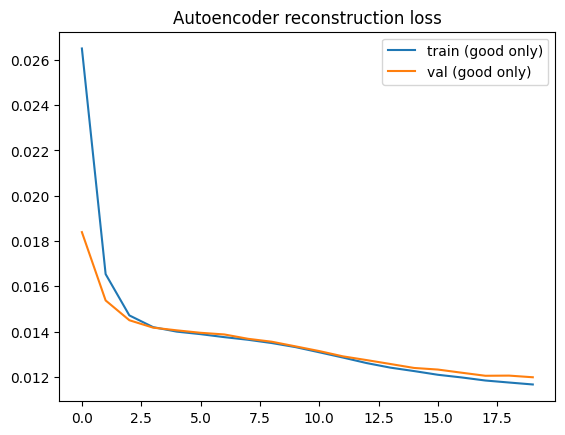

In [18]:
plt.plot(ae_history['train_loss'], label='train (good only)')
plt.plot(ae_history['val_loss'], label='val (good only)')
plt.title('Autoencoder reconstruction loss')
plt.legend()
plt.show()

## 11. Anomaly score = reconstruction error
Per-pixel squared error between input and reconstruction. Mean error over the image = **anomaly score**; the per-pixel error map = the **localization heatmap**.

In [19]:
def compute_anomaly_map(model, image_tensor, topk_frac=0.05):
    # NOTE: per-class breakdown showed 'thread'/'hole'/'cut' scoring well
    # above 'good', but 'color' and 'metal_contamination' barely separated
    # from it (color even scored slightly BELOW good on average). Root
    # cause: anomaly_score was error_map.mean() -- a flat average over all
    # 4,096 pixels. A metal fleck or faint stain only disturbs a small
    # patch of the image, so that hot spot gets diluted almost to nothing
    # once averaged against a large, well-reconstructed background. Wider
    # defects (thread breaks disrupting the weave over a larger area)
    # survive that averaging; small localized ones don't.
    # Fix: score = mean of the top-k% highest-error pixels, not all of
    # them. A genuinely clean image has no hot spot anywhere, so this stays
    # low; an image with even a small anomalous patch now has that patch
    # dominate the score instead of being averaged away.
    model.eval()
    with torch.no_grad():
        x = image_tensor.unsqueeze(0).to(device)
        recon = model(x)
        error_map = (x - recon) ** 2
        error_map = error_map.squeeze(0).mean(dim=0).cpu().numpy()  # (H, W)

    flat = error_map.flatten()
    k = max(1, int(len(flat) * topk_frac))
    top_k_vals = np.partition(flat, -k)[-k:]
    anomaly_score = float(top_k_vals.mean())
    return error_map, anomaly_score

## 12. Visualize localization on a few defective test images

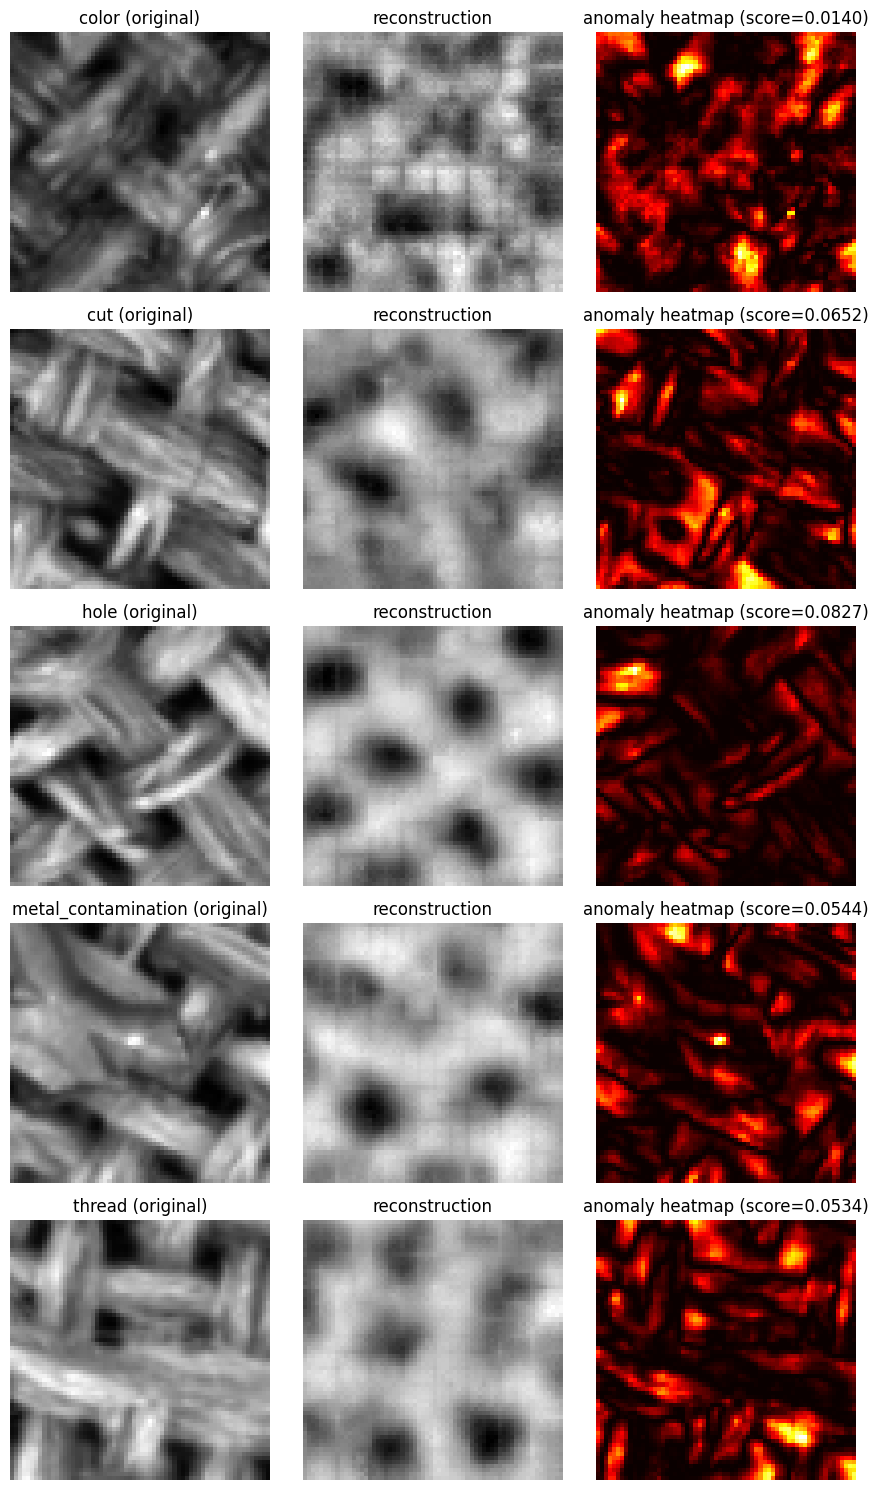

In [20]:
examples = {}
for i in range(len(test_dataset)):
    img, label = test_dataset[i]
    cls_name = label_encoder.classes_[label]
    if cls_name != 'good' and cls_name not in examples:
        examples[cls_name] = img
    if len(examples) == NUM_CLASSES - 1:
        break

fig, axes = plt.subplots(len(examples), 3, figsize=(9, 3 * len(examples)))
for row, (cls_name, img) in enumerate(examples.items()):
    error_map, score = compute_anomaly_map(autoencoder, img)
    img_np = img.numpy()[0]

    with torch.no_grad():
        recon = autoencoder(img.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()[0]

    axes[row, 0].imshow(img_np, cmap='gray'); axes[row, 0].set_title(f'{cls_name} (original)'); axes[row, 0].axis('off')
    axes[row, 1].imshow(recon, cmap='gray'); axes[row, 1].set_title('reconstruction'); axes[row, 1].axis('off')
    axes[row, 2].imshow(error_map, cmap='hot'); axes[row, 2].set_title(f'anomaly heatmap (score={score:.4f})'); axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

## 13. Choose a decision threshold and evaluate as anomaly detector
Score every test image (good + all defect types), treat this as binary: `good` = normal, everything else = anomalous.

In [21]:
from sklearn.metrics import roc_auc_score, precision_recall_curve, classification_report

all_scores, all_binary_labels = [], []

for i in range(len(test_dataset)):
    img, label = test_dataset[i]
    _, score = compute_anomaly_map(autoencoder, img)
    all_scores.append(score)
    all_binary_labels.append(0 if label_encoder.classes_[label] == 'good' else 1)

all_scores = np.array(all_scores)
all_binary_labels = np.array(all_binary_labels)

auc = roc_auc_score(all_binary_labels, all_scores)
print(f'ROC-AUC: {auc:.4f}')

ROC-AUC: 0.7180


In [22]:
# NOTE: the previous approach picked a threshold by maximizing F1 against
# TEST-set labels. Two problems with that: (1) ~83% of the test set is
# anomalous, so F1 for the "anomalous" class is trivially maximized by a
# near-zero threshold that flags almost everything -- which is exactly the
# degenerate result seen before (recall 1.0, precision 0 for "good"), and
# tells you nothing about real detection ability; (2) choosing a threshold
# by scanning test labels at all is a mild form of tuning on the test set.
#
# Fix: set the threshold from the autoencoder's own reconstruction-error
# distribution on held-out GOOD validation images only (never used for
# early stopping either) -- e.g. "flag anything reconstructed worse than
# 95% of normal fabric ever is." This never looks at test labels.
val_good_scores = []
for i in range(len(val_good_dataset)):
    img, _ = val_good_dataset[i]
    _, score = compute_anomaly_map(autoencoder, img)
    val_good_scores.append(score)
val_good_scores = np.array(val_good_scores)

threshold = np.percentile(val_good_scores, 95)
print(f'Threshold (95th percentile of held-out GOOD validation reconstruction error): {threshold:.5f}')

preds_at_threshold = (all_scores >= threshold).astype(int)
print()
print(classification_report(all_binary_labels, preds_at_threshold, target_names=['good', 'anomalous']))

Threshold (95th percentile of held-out GOOD validation reconstruction error): 0.08814

              precision    recall  f1-score   support

        good       0.22      0.95      0.36      2440
   anomalous       0.97      0.31      0.48     11968

    accuracy                           0.42     14408
   macro avg       0.60      0.63      0.42     14408
weighted avg       0.84      0.42      0.46     14408



## 13b. Per-class breakdown
ROC-AUC and one aggregate classification report hide which specific defect types the detector actually catches. `good`'s "flagged" rate here is really its false-positive rate (should land near 5%, since the threshold is the 95th percentile of good-only scores); every other class's "flagged" rate is its recall.

In [23]:
per_class_df = pd.DataFrame({
    'class': [label_encoder.classes_[l] for l in test_split_full['label']],
    'score': all_scores,
})
per_class_df['flagged'] = per_class_df['score'] >= threshold

print('Mean anomaly score per class (higher = more different from normal fabric):')
print(per_class_df.groupby('class')['score'].mean().sort_values(ascending=False))
print()
print(f'Flagged rate per class at threshold={threshold:.5f}')
print('(for "good" this is the false-positive rate; for everything else it is recall):')
print(per_class_df.groupby('class')['flagged'].mean().sort_values(ascending=False))

Mean anomaly score per class (higher = more different from normal fabric):
class
thread                 0.092098
metal_contamination    0.089191
hole                   0.085186
cut                    0.077314
good                   0.062480
color                  0.062307
Name: score, dtype: float64

Flagged rate per class at threshold=0.08814
(for "good" this is the false-positive rate; for everything else it is recall):
class
thread                 0.420856
hole                   0.379559
metal_contamination    0.351644
cut                    0.234336
color                  0.187864
good                   0.046311
Name: flagged, dtype: float64


## 14. Save the autoencoder to Drive

In [24]:
AE_SAVE_PATH = BASE_DIR + 'anomaly_autoencoder.pt'
torch.save(autoencoder.state_dict(), AE_SAVE_PATH)
print('Saved to', AE_SAVE_PATH)

Saved to /content/drive/MyDrive/textile/anomaly_autoencoder.pt
